# 02 — Préparation : construction de la cible RUL et normalisation (FD001)

**Objectif** : construire la cible RUL définitive (écrêtée à 125 cycles), retirer les capteurs constants identifiés en exploration, et normaliser les capteurs par moteur. Le résultat est sauvegardé dans `data/interim/`.

In [1]:
# --- Imports et configuration ---
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_subset, SENSOR_COLUMNS

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

SUBSET = "FD001"
RUL_CLIP = 125

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "preparation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df_train, df_test, df_rul = load_subset(SUBSET)

print(f"train : {df_train.shape}")
print(f"test  : {df_test.shape}")

train : (20631, 26)
test  : (13096, 26)


## 1. Construction de la cible RUL (train)

Pour chaque cycle, la RUL est le nombre de cycles restants avant la panne : cycle maximal du moteur moins cycle actuel, plafonné à 125.

In [3]:
df_train["RUL"] = df_train.groupby("unit_number")["time_in_cycles"].transform("max") - df_train["time_in_cycles"]
df_train["RUL"] = df_train["RUL"].clip(upper=RUL_CLIP)

print(df_train["RUL"].describe())

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


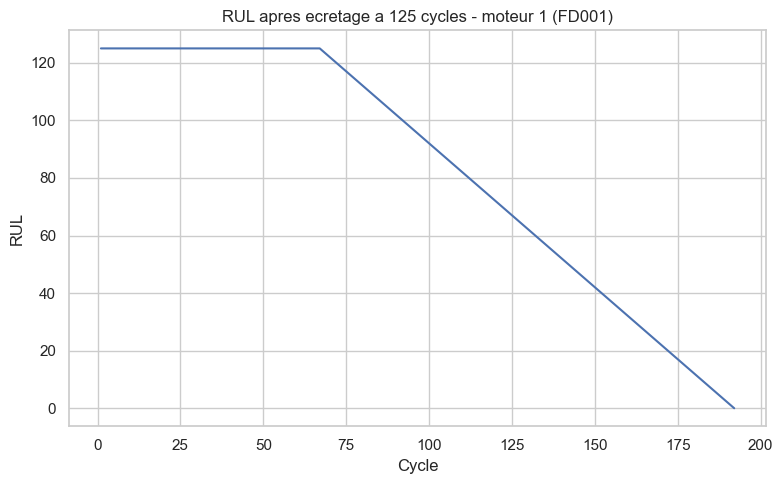

In [4]:
exemple_moteur = df_train[df_train["unit_number"] == 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(exemple_moteur["time_in_cycles"], exemple_moteur["RUL"])
ax.set_xlabel("Cycle")
ax.set_ylabel("RUL")
ax.set_title(f"RUL apres ecretage a {RUL_CLIP} cycles - moteur 1 ({SUBSET})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rul_ecretee_exemple.png")
plt.show()

**Interprétation** : au moins un quart des cycles ont une RUL à 125 (le plafond) — logique, une bonne partie de la vie d'un moteur se déroule loin de la panne. Le graphique du moteur 1 montre bien la forme attendue : plateau à 125 puis descente régulière jusqu'à 0.

## 2. RUL du jeu de test

Le test s'arrête avant la panne : on ne connaît la RUL réelle qu'au dernier cycle enregistré de chaque moteur — c'est la valeur donnée dans `RUL_FD001.txt`. On applique le même écrêtage à 125 pour rester cohérent avec la cible du train.

In [5]:
df_rul_test = df_rul.copy()
df_rul_test["unit_number"] = df_rul_test.index + 1
df_rul_test = df_rul_test.rename(columns={"RUL": "RUL_finale"})
df_rul_test["RUL_finale"] = df_rul_test["RUL_finale"].clip(upper=RUL_CLIP)

dernier_cycle_test = df_test.groupby("unit_number")["time_in_cycles"].max().reset_index()
dernier_cycle_test = dernier_cycle_test.merge(df_rul_test, on="unit_number")

print(dernier_cycle_test.head())
print()
print(dernier_cycle_test["RUL_finale"].describe())

   unit_number  time_in_cycles  RUL_finale
0            1              31         112
1            2              49          98
2            3             126          69
3            4             106          82
4            5              98          91

count    100.000000
mean      74.450000
std       40.275158
min        7.000000
25%       32.750000
50%       86.000000
75%      112.250000
max      125.000000
Name: RUL_finale, dtype: float64


**Interprétation** : la RUL réelle des moteurs test va de 7 à 125 cycles au dernier point observé. Le minimum de 7 est notable : ce moteur a été arrêté d'enregistrer alors qu'il ne lui restait presque plus rien avant la panne — un cas particulièrement difficile à prédire correctement.

## 3. Suppression des capteurs constants

On retire les capteurs identifiés en exploration comme quasi constants, en réutilisant directement la liste sauvegardée dans `config/fd001_capteurs_exclus.json`.

In [6]:
with open(PROJECT_ROOT / "config" / "fd001_capteurs_exclus.json", encoding="utf-8") as f:
    config_exclusion = json.load(f)

capteurs_exclus = config_exclusion["capteurs_exclus"]
print("Colonnes retirees :", capteurs_exclus)

df_train = df_train.drop(columns=capteurs_exclus)
df_test = df_test.drop(columns=capteurs_exclus)

capteurs_retenus = [c for c in SENSOR_COLUMNS if c not in capteurs_exclus]
print(f"{len(capteurs_retenus)} capteurs retenus sur {len(SENSOR_COLUMNS)}")

# Cast en float : certaines colonnes sont lues en int64 (valeurs entieres),
# ce qui empecherait d'y ecrire des valeurs normalisees (0.0-1.0) proprement.
df_train[capteurs_retenus] = df_train[capteurs_retenus].astype(float)
df_test[capteurs_retenus] = df_test[capteurs_retenus].astype(float)

Colonnes retirees : ['sensor_1', 'op_setting_3', 'sensor_10', 'sensor_19', 'sensor_18', 'sensor_16', 'sensor_5']
15 capteurs retenus sur 21


**Interprétation** : 15 capteurs sur 21 sont conservés — les 6 retirés sont exactement ceux repérés comme constants en exploration.

## 4. Normalisation des capteurs

Chaque capteur est ramené entre 0 et 1 à l'aide d'un scaler unique, calculé une seule fois sur l'ensemble du train, puis appliqué tel quel au train et au test. Normaliser moteur par moteur poserait problème sur le test : ses trajectoires étant tronquées, le minimum et le maximum observés pour un moteur ne représenteraient qu'une fraction de sa vraie plage de variation, ce qui fausserait l'échelle.

In [7]:
scaler = MinMaxScaler()
scaler.fit(df_train[capteurs_retenus])

df_train[capteurs_retenus] = scaler.transform(df_train[capteurs_retenus])
df_test[capteurs_retenus] = scaler.transform(df_test[capteurs_retenus])

print("Train :")
print(df_train[capteurs_retenus].describe().loc[["min", "max"]])
print()
print("Test :")
print(df_test[capteurs_retenus].describe().loc[["min", "max"]])

Train :
     sensor_2  sensor_3  sensor_4  sensor_6  sensor_7  sensor_8  sensor_9  \
min       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
max       1.0       1.0       1.0       1.0       1.0       1.0       1.0   

     sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  \
min        0.0        0.0        0.0        0.0        0.0        0.0   
max        1.0        1.0        1.0        1.0        1.0        1.0   

     sensor_20  sensor_21  
min        0.0        0.0  
max        1.0        1.0  

Test :
     sensor_2  sensor_3  sensor_4  sensor_6  sensor_7  sensor_8  sensor_9  \
min -0.024096 -0.043601  0.036124       0.0  0.165862 -0.015152  0.012564   
max  0.930723  0.795945  0.862762       1.0  0.964573  0.606061  0.598133   

     sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  \
min  -0.029762   0.147122   0.014706   0.044174   0.030396   0.083333   
max   0.839286   1.081023   0.647059   0.622046   0.833013   0.750000 

**Interprétation** : sur le train, chaque capteur couvre exactement [0, 1] — c'est la définition même du scaler. Sur le test, les valeurs restent presque toutes dans cette même plage, avec de légers dépassements ponctuels (par exemple sensor_12 atteint 1,08) : un moteur test peut afficher, à un instant donné, une valeur jamais observée sur le train à ce stade de vie — c'est attendu, et surtout cohérent avec la vraie échelle du train, contrairement à une normalisation propre à chaque moteur.

In [8]:
n_nan_train = df_train[capteurs_retenus].isna().sum().sum()
n_nan_test = df_test[capteurs_retenus].isna().sum().sum()

assert n_nan_train == 0 and n_nan_test == 0, "Valeurs manquantes inattendues apres normalisation."
print("Aucune valeur manquante apres normalisation.")

Aucune valeur manquante apres normalisation.


**Interprétation** : aucune valeur manquante, comme attendu avec un scaler unique appliqué à l'ensemble des données.

## 5. Sauvegarde

Les jeux de données préparés sont sauvegardés dans `data/interim/`, prêts pour l'étape suivante.

In [9]:
df_train.to_parquet(INTERIM_DIR / f"train_{SUBSET}_prepared.parquet", index=False)
df_test.to_parquet(INTERIM_DIR / f"test_{SUBSET}_prepared.parquet", index=False)
dernier_cycle_test.to_csv(INTERIM_DIR / f"rul_test_{SUBSET}_prepared.csv", index=False)

print("Fichiers sauvegardes dans", INTERIM_DIR)
for f in sorted(INTERIM_DIR.glob(f"*{SUBSET}*")):
    print(" -", f.name)

Fichiers sauvegardes dans C:\cmapss-prediction-rul\data\interim
 - rul_test_FD001_prepared.csv
 - test_FD001_prepared.parquet
 - train_FD001_prepared.parquet


## Synthèse

Cette étape a produit :
- une cible RUL construite et écrêtée à 125, pour le train comme pour le test ;
- un jeu de données réduit aux capteurs informatifs ;
- des capteurs normalisés entre 0 et 1 à l'aide d'un scaler unique, cohérent entre train et test.